In [6]:
!pip install datasets transformers scikit-learn pandas numpy matplotlib seaborn torch

In [7]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  


In [8]:
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

df = pd.concat([train_df, val_df, test_df])

df.head()

,text,variety,source,Sentiment,Sarcasm
0,I'm a member of the Green Party but I'll be vo...,en-UK,Reddit,0.0,0.0
1,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
2,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
3,Firstly the staff seemed as if they did n't wa...,en-UK,Google,0.0,0.0
4,We came for lunch and enjoyed the food we orde...,en-UK,Google,1.0,0.0


In [9]:
print("Dataset shape:", df.shape)
print(df.columns)

df['variety'].value_counts()

Dataset shape: (6243, 5)
Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm'], dtype='object')


,count
variety,
en-IN,2332
en-UK,2004
en-AU,1907


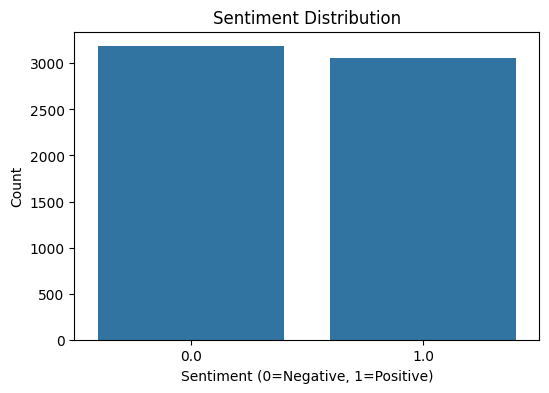

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Positive)")
plt.ylabel("Count")
plt.show()

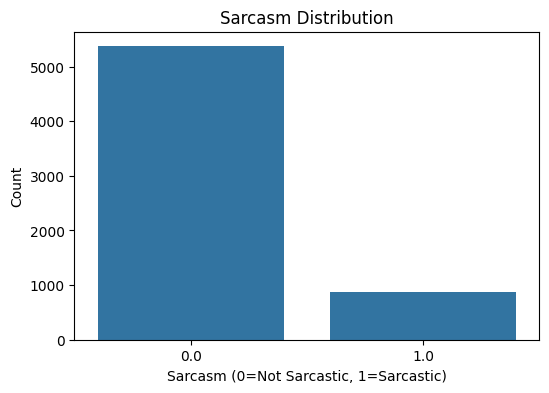

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sarcasm')
plt.title("Sarcasm Distribution")
plt.xlabel("Sarcasm (0=Not Sarcastic, 1=Sarcastic)")
plt.ylabel("Count")
plt.show()

In [12]:
X_train = train_df["text"]
y_train = train_df["Sentiment"]

X_test = test_df["text"]
y_test = test_df["Sentiment"]

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import classification_report, f1_score

pred_lr = model_lr.predict(X_test_tfidf)

print(classification_report(y_test, pred_lr))

macro_f1 = f1_score(y_test, pred_lr, average="macro")

print("Macro F1:", macro_f1)

              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84      1117
         1.0       0.86      0.79      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.84      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183

Macro F1: 0.8326168504637619


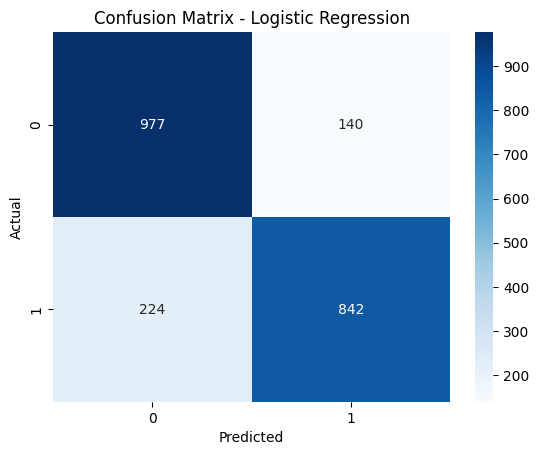

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [17]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

In [18]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3747 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

In [19]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

In [21]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

In [ ]:
trainer.train()

In [ ]:
predictions = train.predict(test_dataset)

import numpy as np

preds = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

In [ ]:
predictions = trainer.predict(test_dataset)

import numpy as np

preds = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import classification_report

print(classification_report(y_test, preds))